In [26]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(".."))
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path(os.path.abspath("."))

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

In [27]:
RESEARCH_DATASET_DIR = (PROJECT_ROOT / "data" / "research_processed_smoke_auto").resolve()
RESEARCH_MODEL_DIR = (PROJECT_ROOT / "models" / "research_smoke_auto").resolve()
RESEARCH_RESULTS_DIR = (PROJECT_ROOT / "results" / "research_smoke_auto").resolve()

# 03 Evaluate

This notebook loads the trained model, runs sequential inference, computes anomaly scores and reconstruction errors, evaluates early detection, and saves outputs under `results/research_smoke_auto/`.

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

from src.config import EvalConfig
from src.evaluate import evaluate_model
from src.utils import read_json

## Sequential Inference And Anomaly Score Calculation

In [29]:
cfg = EvalConfig(
    dataset_dir=RESEARCH_DATASET_DIR,
    model_dir=RESEARCH_MODEL_DIR,
    output_dir=RESEARCH_RESULTS_DIR,
    split="test",
    top_k_features=5,
    use_synthetic_injection=True,
    include_gpt_in_stream=True,
    telegram_enabled=True,
)
eval_summary = evaluate_model(cfg)
eval_summary["evaluation_summary"]

{'threshold': 5.465899467468262,
 'precision': 0.16326530612244897,
 'recall': 0.02666666666666667,
 'f1': 0.045845272206303724,
 'pr_auc': 0.27352578318303505,
 'roc_auc': 0.8323572110792742,
 'num_windows': 3790,
 'num_positive_windows': 300,
 'num_realtime_alerts': 49,
 'num_gpt_decisions': 49,
 'split': 'test',
 'telegram_notifications_sent': 4,
 'telegram_notifications_failed': 0}

In [30]:
predictions = pd.read_csv(cfg.output_dir / "window_level_predictions.csv")
predictions.head()

,window_id,entity_id,container_id,machine_id,end_time,split,anomaly_score,threshold,score_over_threshold,feature_error_vector,top_feature_rank,top_k_features,top_k_feature_errors,label,predicted_label,event_id
0,0,c_10077,c_10077,m_3597,139980,test,0.080587,5.465899,-5.385313,"[0.07452138513326645, 0.0020625886972993612, 0...","[7, 0, 2, 1, 3, 6, 4, 5]","['disk_io', 'cpu_util', 'cpi', 'mem_util', 'me...","[0.5617099404335022, 0.07452138513326645, 0.00...",0,0,-1
1,1,c_10077,c_10077,m_3597,162780,test,0.084030,5.465899,-5.381869,"[0.06504624336957932, 0.0030672175344079733, 0...","[7, 0, 2, 1, 3, 6, 4, 5]","['disk_io', 'cpu_util', 'cpi', 'mem_util', 'me...","[0.59725022315979, 0.06504624336957932, 0.0035...",0,0,-1
2,2,c_10077,c_10077,m_3597,167520,test,0.093646,5.465899,-5.372254,"[0.06927447766065598, 0.003614868735894561, 0....","[7, 0, 2, 1, 3, 6, 5, 4]","['disk_io', 'cpu_util', 'cpi', 'mem_util', 'me...","[0.6684882640838623, 0.06927447766065598, 0.00...",0,0,-1
3,3,c_10066,c_10066,m_658,234470,test,0.125585,5.465899,-5.340315,"[0.03551137074828148, 0.01056391466408968, 0.0...","[7, 0, 1, 2, 3, 6, 5, 4]","['disk_io', 'cpu_util', 'mem_util', 'cpi', 'me...","[0.9419098496437073, 0.03551137074828148, 0.01...",0,0,-1
4,4,c_10066,c_10066,m_658,238770,test,1.137993,5.465899,-4.327906,"[0.11708001047372818, 0.06755834072828293, 0.0...","[3, 7, 0, 1, 6, 5, 2, 4]","['mem_gps', 'disk_io', 'cpu_util', 'mem_util',...","[5.451909065246582, 3.382382869720459, 0.11708...",1,0,0


## Feature-Wise Reconstruction Error And Top-k Anomalous Features

In [31]:
predictions[
    [
        "window_id",
        "container_id",
        "anomaly_score",
        "top_k_features",
        "top_k_feature_errors",
    ]
].sort_values("anomaly_score", ascending=False).head(10)

,window_id,container_id,anomaly_score,top_k_features,top_k_feature_errors
440,440,c_10015,15.401431,"['mem_gps', 'mpki', 'disk_io', 'cpi', 'cpu_util']","[117.78689575195312, 3.6229658126831055, 0.743..."
281,281,c_10015,15.385618,"['mem_gps', 'mpki', 'disk_io', 'cpi', 'cpu_util']","[117.753173828125, 3.3260743618011475, 0.91001..."
378,378,c_10015,15.344934,"['mem_gps', 'mpki', 'disk_io', 'cpi', 'cpu_util']","[117.47628021240234, 3.4102370738983154, 0.803..."
554,554,c_10015,15.281445,"['mem_gps', 'mpki', 'disk_io', 'cpi', 'cpu_util']","[117.33273315429688, 3.139058828353882, 0.6716..."
1082,1082,c_100,12.262834,"['mem_gps', 'mpki', 'cpu_util', 'disk_io', 'cpi']","[91.11062622070312, 3.9059388637542725, 1.3792..."
1227,1227,c_100,12.028608,"['mem_gps', 'mpki', 'cpu_util', 'disk_io', 'cpi']","[92.48473358154297, 2.0964269638061523, 0.8413..."
1288,1288,c_100,11.627061,"['mem_gps', 'mpki', 'cpu_util', 'disk_io', 'cpi']","[90.23172760009766, 1.478630542755127, 0.64302..."
892,892,c_100,11.380765,"['mem_gps', 'mpki', 'cpu_util', 'disk_io', 'cpi']","[83.59000396728516, 3.9753241539001465, 1.5424..."
1168,1168,c_100,11.169371,"['mem_gps', 'mpki', 'cpu_util', 'disk_io', 'cpi']","[84.22518920898438, 2.8906443119049072, 0.9932..."
1558,1558,c_10057,9.684126,"['mem_gps', 'mpki', 'disk_io', 'net_in', 'net_...","[71.05363464355469, 5.090799808502197, 0.78916..."


## Precision, Recall, F1, PR-AUC, And ROC-AUC

In [32]:
evaluation_summary = read_json(cfg.output_dir / "evaluation_summary.json")
evaluation_summary

{'threshold': 5.465899467468262,
 'precision': 0.16326530612244897,
 'recall': 0.02666666666666667,
 'f1': 0.045845272206303724,
 'pr_auc': 0.27352578318303505,
 'roc_auc': 0.8323572110792742,
 'num_windows': 3790,
 'num_positive_windows': 300,
 'num_realtime_alerts': 49,
 'num_gpt_decisions': 49,
 'split': 'test',
 'telegram_notifications_sent': 4,
 'telegram_notifications_failed': 0}

## Strict And Relaxed Early Detection Evaluation

In [33]:
event_metrics = read_json(cfg.output_dir / "event_metrics.json")
event_metrics

{'num_events': 75,
 'strict_detection_rate': 0.02666666666666667,
 'relaxed_detection_rate': 0.02666666666666667,
 'mean_detection_delay': 0.0}

## Streaming-Style Inference Flow

In [34]:
realtime_stream = pd.read_csv(cfg.output_dir / "realtime_stream_predictions.csv")
realtime_stream.head()

,window_id,entity_id,container_id,machine_id,end_time,split,anomaly_score,threshold,score_over_threshold,feature_error_vector,...,predicted_label,event_id,realtime_step,alert_ready,gpt_triggered,gpt_label,gpt_severity,gpt_recommended_action,gpt_explanation,compact_anomaly_summary
0,0,c_10077,c_10077,m_3597,139980,test,0.080587,5.465899,-5.385313,"[0.07452138513326645, 0.0020625886972993612, 0...",...,0,-1,0,False,False,NaN,NaN,NaN,NaN,"{""window_id"": 0, ""container_id"": ""c_10077"", ""m..."
1,1,c_10077,c_10077,m_3597,162780,test,0.084030,5.465899,-5.381869,"[0.06504624336957932, 0.0030672175344079733, 0...",...,0,-1,1,False,False,NaN,NaN,NaN,NaN,"{""window_id"": 1, ""container_id"": ""c_10077"", ""m..."
2,2,c_10077,c_10077,m_3597,167520,test,0.093646,5.465899,-5.372254,"[0.06927447766065598, 0.003614868735894561, 0....",...,0,-1,2,False,False,NaN,NaN,NaN,NaN,"{""window_id"": 2, ""container_id"": ""c_10077"", ""m..."
3,3,c_10066,c_10066,m_658,234470,test,0.125585,5.465899,-5.340315,"[0.03551137074828148, 0.01056391466408968, 0.0...",...,0,-1,3,False,False,NaN,NaN,NaN,NaN,"{""window_id"": 3, ""container_id"": ""c_10066"", ""m..."
4,4,c_10066,c_10066,m_658,238770,test,1.137993,5.465899,-4.327906,"[0.11708001047372818, 0.06755834072828293, 0.0...",...,0,0,4,False,False,NaN,NaN,NaN,NaN,"{""window_id"": 4, ""container_id"": ""c_10066"", ""m..."


## Visualizations

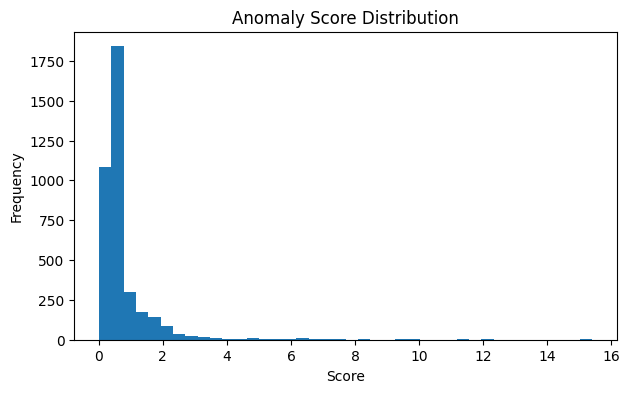

In [35]:
plt.figure(figsize=(7, 4))
predictions["anomaly_score"].plot(kind="hist", bins=40)
plt.title("Anomaly Score Distribution")
plt.xlabel("Score")
plt.show()

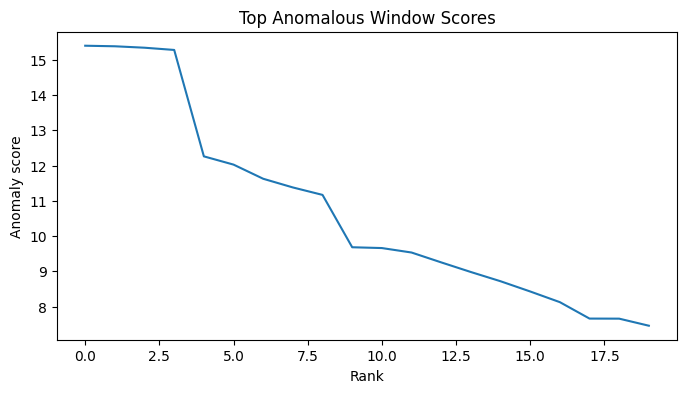

In [36]:
top_windows = pd.read_csv(cfg.output_dir / "top_anomalous_windows.csv")
plt.figure(figsize=(8, 4))
plt.plot(top_windows["anomaly_score"].head(20).to_numpy())
plt.title("Top Anomalous Window Scores")
plt.xlabel("Rank")
plt.ylabel("Anomaly score")
plt.show()